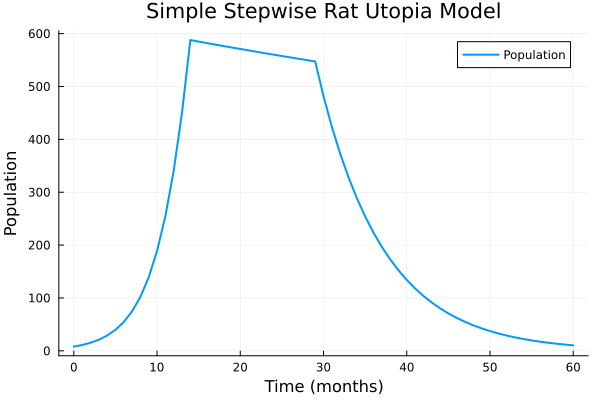

In [9]:
using Plots

# Simple stepwise population model based on uncertainty phases
function simple_simulate(months::Int)
    # Parameters (tuned for boom-plateau-collapse)
    initial_pop = 8.0
    carrying_capacity = 2400.0
    base_death_rate = 0.02  # Fraction dying per month
    extra_death_rate_low_H = 0.1  # Extra for collapse phase

    # Hardcoded phases based on uncertainty (time approximates generations)
    # Phase 1 (high H=ln(3), months 0-15): Explosive growth
    # Phase 2 (medium H=ln(2), months 15-30): Steady state (repro balances death)
    # Phase 3 (low H=0, months 30+): No repro, high death

    population = zeros(months + 1)
    population[1] = initial_pop

    for month in 1:months
        pop = population[month]
        if month < 15  # High uncertainty: huge growth
            repro_rate = 0.4  # High to boom
        elseif month < 30  # Medium uncertainty: steady state
            repro_rate = base_death_rate  # Balance for plateau
        else  # No uncertainty: collapse
            repro_rate = 0.0  # No reproduction
        end

        # Logistic growth term scaled by repro_rate, minus deaths
        growth = repro_rate * pop * (1 - pop / carrying_capacity)
        deaths = base_death_rate * pop
        if month >= 30
            deaths += extra_death_rate_low_H * pop  # Exaggerated death
        end
        new_pop = pop + growth - deaths
        population[month + 1] = max(new_pop, 0.0)  # No negative pop
    end

    return population
end

# Run and plot
months = 60
pop = simple_simulate(months)
p=plot(0:months, pop, label="Population", xlabel="Time (months)", ylabel="Population", title="Simple Stepwise Rat Utopia Model", grid=true, lw=2)
savefig("simple_rat_utopia.png")
display(p)

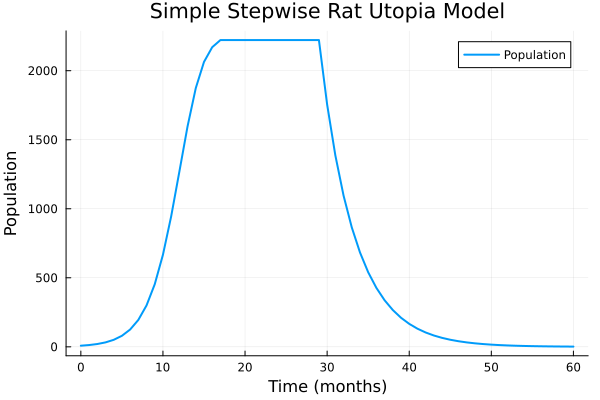

In [10]:
using Plots

# Simple stepwise population model based on uncertainty phases
function simple_simulate(months::Int)
    # Parameters (tuned for boom-plateau-collapse)
    initial_pop = 8.0
    carrying_capacity = 2300.0
    base_death_rate = 0.01  # Fraction dying per month
    extra_death_rate_low_H = 0.2  # Extra for collapse phase

    # Hardcoded phases based on uncertainty (time approximates generations)
    # Phase 1 (high H=ln(3), months 1-17): Explosive growth
    # Phase 2 (medium H=ln(2), months 18-29): Steady state (flat plateau)
    # Phase 3 (low H=0, months 30+): No repro, high death

    population = zeros(months + 1)
    population[1] = initial_pop

    for month in 1:months
        pop = population[month]
        if month < 18  # High uncertainty: huge growth
            repro_rate = 0.6  # High to boom
            growth = repro_rate * pop * (1 - pop / carrying_capacity)
        elseif month < 30  # Medium uncertainty: steady state
            growth = base_death_rate * pop  # Balance for flat plateau
        else  # No uncertainty: collapse
            growth = 0.0  # No reproduction
        end

        deaths = base_death_rate * pop
        if month >= 30
            deaths += extra_death_rate_low_H * pop  # Exaggerated death
        end
        new_pop = pop + growth - deaths
        population[month + 1] = max(new_pop, 0.0)  # No negative pop
    end
    return population
end

# Run and plot
months = 60
pop = simple_simulate(months)
p = plot(0:months, pop, label="Population", xlabel="Time (months)", ylabel="Population", title="Simple Stepwise Rat Utopia Model", grid=true, lw=2)
savefig("simple_rat_utopia2.png")
display(p)

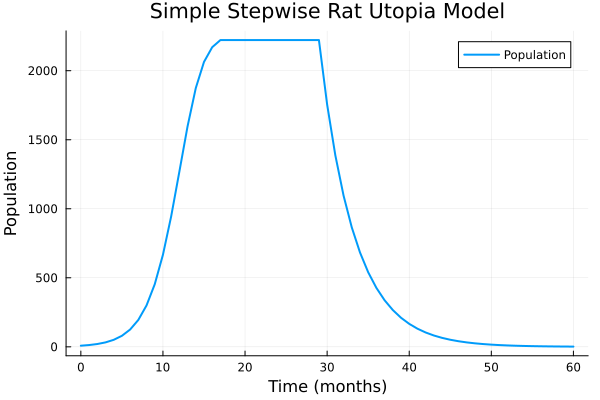

In [11]:
using Plots

# Simple stepwise population model based on uncertainty phases
function simple_simulate(months::Int)
    # Parameters (tuned for boom-plateau-collapse)
    initial_pop = 8.0
    carrying_capacity = 2300.0
    base_death_rate = 0.01  # Fraction dying per month
    extra_death_rate_low_H = 0.2  # Extra for collapse phase

    # Hardcoded phases based on uncertainty (time approximates generations)
    # Phase 1 (p=1/3, high H=ln(3), months 1-9): Explosive growth (gen 0)
    # Phase 2 (p=1/3, high H=ln(3), months 10-17): Continued growth (gen 1)
    # Phase 3 (p=1/2, medium H=ln(2), months 18-29): Steady state (gen 2)
    # Phase 4 (p=1, low H=0, months 30+): Collapse (gen 3)

    population = zeros(months + 1)
    population[1] = initial_pop

    for month in 1:months
        pop = population[month]

        # Compute entropy based on phase and p
        if month < 18  # Phases 1 and 2: p=1/3, three strata
            p = 1/3
            strata = 3
        elseif month < 30  # Phase 3: p=1/2, two strata
            p = 1/2
            strata = 2
        else  # Phase 4: p=1, one stratum
            p = 1.0
            strata = 1
        end
        # Entropy H = -sum p_i log(p_i); since uniform, H = -strata * p * log(p)
        H = (p == 1.0) ? 0.0 : -strata * p * log(p)  # Avoid log(1)=0 issue

        # Switch based on entropy for rates
        if H ≈ log(3)  # High uncertainty (p=1/3): huge growth
            repro_rate = 0.6
            growth = repro_rate * pop * (1 - pop / carrying_capacity)
        elseif H ≈ log(2)  # Medium uncertainty (p=1/2): steady state
            growth = base_death_rate * pop  # Balance for flat plateau
        else  # No uncertainty (p=1): collapse
            growth = 0.0
        end

        deaths = base_death_rate * pop
        if H == 0.0
            deaths += extra_death_rate_low_H * pop  # Exaggerated death
        end
        new_pop = pop + growth - deaths
        population[month + 1] = max(new_pop, 0.0)  # No negative pop
    end
    return population
end

# Run and plot
months = 60
pop = simple_simulate(months)
p = plot(0:months, pop, label="Population", xlabel="Time (months)", ylabel="Population", title="Simple Stepwise Rat Utopia Model", grid=true, lw=2)
savefig("simple_rat_utopia3.png")
display(p)

In [17]:
using Agents
using Random
using Plots
using Statistics

Installing/Loading required packages...
=== Rat Utopia Agent-Based Model ===
Simulating population dynamics with pecking order uncertainty
Initial population: 8

Month 10:
  Population: 98
  Entropy: 1.099
  Generations: Gen0=76, Gen1=22, Gen2=0, Gen3=0
  Strata: Dom=41, Int=32, Sub=25

Month 20:
  Population: 560
  Entropy: 0.693
  Generations: Gen0=69, Gen1=487, Gen2=4, Gen3=0
  Strata: Dom=215, Int=202, Sub=143

Month 30:
  Population: 531
  Entropy: 0.0
  Generations: Gen0=51, Gen1=451, Gen2=22, Gen3=7
  Strata: Dom=210, Int=195, Sub=126

Month 40:
  Population: 28
  Entropy: 0.0
  Generations: Gen0=2, Gen1=24, Gen2=2, Gen3=0
  Strata: Dom=8, Int=17, Sub=3

Month 50:
  Population: 2
  Entropy: 0.0
  Generations: Gen0=0, Gen1=2, Gen2=0, Gen3=0
  Strata: Dom=2, Int=0, Sub=0

Month 60:
  Population: 0
  Entropy: 0.0
  Generations: Gen0=0, Gen1=0, Gen2=0, Gen3=0
  Strata: Dom=0, Int=0, Sub=0

Simulation completed!
Final population: 0
Peak population: 566 at month 18

Creating plots...


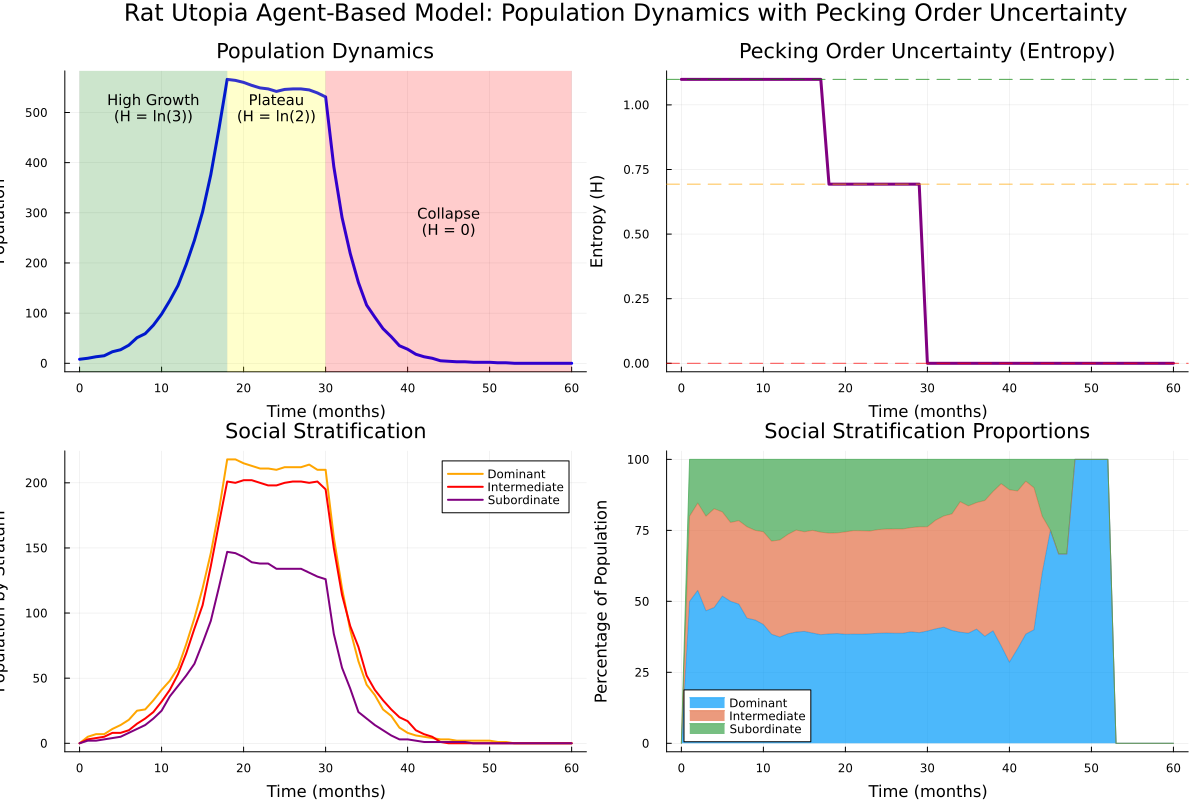

(StandardABM with 0 agents of type Rat
 agents container: Dict
 space: GridSpace with size (50, 50), metric=chebyshev, periodic=false
 scheduler: #122
 properties: reproduction_cooldown, stratum_counts, next_id, entropy_history, base_death_rate, carrying_capacity, population_history, generation_counts, stratum_history, extra_death_rate, month, Plot{Plots.GRBackend() n=14}
Captured extra kwargs:
  Series{12}:
    colors: [:orange :red :purple]
  Series{13}:
    colors: [:orange :red :purple]
  Series{14}:
    colors: [:orange :red :purple]
)

In [19]:

# Define the Rat agent
mutable struct Rat <: AbstractAgent
    id::Int
    pos::Tuple{Int, Int}
    age::Int                    # Age in months
    generation::Int             # Generation number (0, 1, 2, 3)
    stratum::Int               # Social stratum (1=dominant, 2=intermediate, 3=subordinate)
    reproductive_status::Bool   # Can reproduce or not
    last_reproduction::Int      # Last month of reproduction
end

# Initialize the model
function initialize_model(;
    initial_population = 8,
    grid_size = (50, 50),
    carrying_capacity = 2300,
    seed = 42
)
    
    Random.seed!(seed)
    
    # Create space
    space = GridSpace(grid_size, periodic = false)
    
    # Model properties
    properties = Dict(
        :month => 0,
        :carrying_capacity => carrying_capacity,
        :population_history => Int[],
        :generation_counts => Dict(0 => 0, 1 => 0, 2 => 0, 3 => 0),
        :stratum_counts => Dict(1 => 0, 2 => 0, 3 => 0),
        :base_death_rate => 0.01,
        :extra_death_rate => 0.2,
        :reproduction_cooldown => 3,
        :next_id => initial_population + 1,
        :entropy_history => Float64[],
        :stratum_history => Dict(1 => Int[], 2 => Int[], 3 => Int[])
    )
    
    # Create model with stepping functions
    model = ABM(Rat, space; properties = properties, 
                agent_step! = agent_step!, model_step! = model_step!,
                scheduler = (model) -> shuffle(collect(allids(model))))
    
    # Add initial population (generation 0)
    for i in 1:initial_population
        pos = random_empty(model)
        if pos !== nothing
            # Assign random stratum for initial population
            stratum = rand(1:3)
            rat = Rat(
                i,                    # id
                pos,                  # position
                0,                    # age
                0,                    # generation
                stratum,              # stratum
                true,                 # reproductive_status
                -999                  # last_reproduction (never reproduced)
            )
            add_agent_own_pos!(rat, model)
            model.month = 0
            model.generation_counts[0] += 1
            model.stratum_counts[stratum] += 1
        end
    end
    
    # Record initial population
    push!(model.population_history, nagents(model))
    
    return model
end

# Calculate pecking order uncertainty (entropy) based on time and social dynamics
function calculate_entropy(month)
    """
    Calculate pecking order uncertainty based on generational phases:
    - Months 0-17: High uncertainty (p=1/3 across 3 strata, H=ln(3))
    - Months 18-29: Medium uncertainty (p=1/2 across 2 strata, H=ln(2))  
    - Months 30+: No uncertainty (p=1, single stratum dominance, H=0)
    """
    if month < 18
        return log(3)  # ≈ 1.099 - High uncertainty drives aggressive reproduction
    elseif month < 30
        return log(2)  # ≈ 0.693 - Medium uncertainty maintains steady state
    else
        return 0.0     # Zero uncertainty leads to reproductive collapse
    end
end

# Determine reproduction rate based on entropy
function get_reproduction_rate(entropy)
    """
    Map entropy levels to reproduction rates:
    - High entropy (ln(3)): Strong reproductive drive due to uncertainty
    - Medium entropy (ln(2)): Balanced reproduction for steady state
    - Zero entropy: Complete reproductive shutdown
    """
    if entropy ≈ log(3)
        return 0.6  # High growth phase
    elseif entropy ≈ log(2)
        return 0.01  # Steady state (balance with death rate)
    else
        return 0.0  # No reproduction in collapse phase
    end
end

# Agent step function - individual rat behavior
function agent_step!(rat, model)
    # Age the rat
    rat.age += 1
    
    # Calculate current entropy and mortality
    entropy = calculate_entropy(model.month)
    death_prob = model.base_death_rate
    
    # Entropy-based mortality effects
    if entropy == 0.0
        # Collapse phase: increased mortality
        death_prob += model.extra_death_rate
        # Subordinate rats suffer additional stress mortality
        if rat.stratum == 3
            death_prob += 0.1
        end
    end
    
    # Age-related mortality
    if rat.age > 18
        death_prob += 0.05
    end
    
    # Death check
    if rand() < death_prob
        remove_agent!(rat, model)
        model.generation_counts[rat.generation] -= 1
        model.stratum_counts[rat.stratum] -= 1
        return
    end
    
    # Reproduction logic
    if rat.reproductive_status && 
       (model.month - rat.last_reproduction) >= model.reproduction_cooldown
        
        base_reproduction_rate = get_reproduction_rate(entropy)
        
        # Individual reproduction probability based on stratum and uncertainty
        stratum_multiplier = Dict(1 => 1.5, 2 => 1.0, 3 => 0.5)  # Dominant > Intermediate > Subordinate
        uncertainty_factor = entropy / log(3)  # Normalize uncertainty to [0,1]
        
        # Age effects on reproduction
        age_factor = if rat.age < 2
            0.5  # Young adults - lower fertility
        elseif rat.age < 12
            1.0  # Prime reproductive age
        else
            0.3  # Older adults - declining fertility
        end
        
        individual_prob = base_reproduction_rate * stratum_multiplier[rat.stratum] * uncertainty_factor * age_factor
        
        # Logistic growth constraint
        current_pop = nagents(model)
        if current_pop >= model.carrying_capacity
            individual_prob *= 0.1  # Severe reduction at capacity
        else
            logistic_factor = 1 - current_pop / model.carrying_capacity
            individual_prob *= logistic_factor
        end
        
        # Attempt reproduction
        if rand() < individual_prob
            offspring_pos = random_empty(model)
            if offspring_pos !== nothing
                # Determine offspring generation based on time
                offspring_generation = if model.month < 9
                    0
                elseif model.month < 18
                    1
                elseif model.month < 27
                    2
                else
                    3
                end
                
                # Stratum inheritance with social mobility
                # Higher uncertainty allows more social mobility
                mobility_prob = uncertainty_factor * 0.4
                offspring_stratum = if rand() < mobility_prob
                    rand(1:3)  # Random stratum assignment
                else
                    rat.stratum  # Inherit parent's stratum
                end
                
                # Create offspring
                offspring = Rat(
                    model.next_id,
                    offspring_pos,
                    0,                           # age
                    offspring_generation,        # generation
                    offspring_stratum,          # stratum
                    true,                       # reproductive_status
                    -999                        # last_reproduction
                )
                
                model.next_id += 1
                add_agent_own_pos!(offspring, model)
                model.generation_counts[offspring_generation] += 1
                model.stratum_counts[offspring_stratum] += 1
                rat.last_reproduction = model.month
            end
        end
    end
    
    # Update reproductive status based on conditions
    if rat.age > 15 || (entropy == 0.0 && rat.stratum == 3)
        rat.reproductive_status = false
    end
end

# Model step function - global dynamics
function model_step!(model)
    model.month += 1
    
    # Record population
    current_pop = nagents(model)
    push!(model.population_history, current_pop)
    
    # Record entropy
    entropy = calculate_entropy(model.month)
    push!(model.entropy_history, entropy)
    
    # Update generation and stratum counts
    gen_counts = Dict(0 => 0, 1 => 0, 2 => 0, 3 => 0)
    stratum_counts = Dict(1 => 0, 2 => 0, 3 => 0)
    
    for rat in allagents(model)
        gen_counts[rat.generation] += 1
        stratum_counts[rat.stratum] += 1
    end
    
    model.generation_counts = gen_counts
    model.stratum_counts = stratum_counts
    
    # Record stratum history
    for stratum in 1:3
        push!(model.stratum_history[stratum], stratum_counts[stratum])
    end
end

# Run simulation with detailed tracking
function run_simulation(months = 60; verbose = true)
    model = initialize_model()
    
    if verbose
        println("=== Rat Utopia Agent-Based Model ===")
        println("Simulating population dynamics with pecking order uncertainty")
        println("Initial population: $(nagents(model))")
        println()
    end
    
    # Run simulation
    for month in 1:months
        step!(model)
        
        # Progress reporting
        if verbose && month % 10 == 0
            current_pop = nagents(model)
            entropy = calculate_entropy(model.month)
            gen_counts = model.generation_counts
            strat_counts = model.stratum_counts
            
            println("Month $month:")
            println("  Population: $current_pop")
            println("  Entropy: $(round(entropy, digits=3))")
            println("  Generations: Gen0=$(gen_counts[0]), Gen1=$(gen_counts[1]), Gen2=$(gen_counts[2]), Gen3=$(gen_counts[3])")
            println("  Strata: Dom=$(strat_counts[1]), Int=$(strat_counts[2]), Sub=$(strat_counts[3])")
            println()
        end
    end
    
    if verbose
        println("Simulation completed!")
        println("Final population: $(model.population_history[end])")
        println("Peak population: $(maximum(model.population_history)) at month $(argmax(model.population_history)-1)")
    end
    
    return model
end

# Create comprehensive plots
function create_plots(model)
    months = 0:length(model.population_history)-1
    
    # Prepare data
    population = model.population_history
    entropy_data = [calculate_entropy(0); model.entropy_history]
    
    # Stratum data
    dominant = [model.stratum_counts[1]; model.stratum_history[1]]
    intermediate = [model.stratum_counts[2]; model.stratum_history[2]]
    subordinate = [model.stratum_counts[3]; model.stratum_history[3]]
    
    # Create subplot layout
    p1 = plot(months, population, 
              linewidth=3, 
              color=:blue,
              title="Population Dynamics",
              xlabel="Time (months)",
              ylabel="Population",
              legend=false,
              grid=true)
    
    # Add phase backgrounds
    vspan!(p1, [0, 18], alpha=0.2, color=:green, label="High Growth")
    vspan!(p1, [18, 30], alpha=0.2, color=:yellow, label="Plateau")
    vspan!(p1, [30, 60], alpha=0.2, color=:red, label="Collapse")
    
    # Add phase annotations
    annotate!(p1, 9, maximum(population)*0.9, text("High Growth\n(H = ln(3))", 10, :center))
    annotate!(p1, 24, maximum(population)*0.9, text("Plateau\n(H = ln(2))", 10, :center))
    annotate!(p1, 45, maximum(population)*0.5, text("Collapse\n(H = 0)", 10, :center))
    
    # Entropy plot
    p2 = plot(months, entropy_data,
              linewidth=3,
              color=:purple,
              title="Pecking Order Uncertainty (Entropy)",
              xlabel="Time (months)",
              ylabel="Entropy (H)",
              legend=false,
              grid=true)
    
    # Add entropy level lines
    hline!(p2, [log(3)], linestyle=:dash, color=:green, alpha=0.7, label="ln(3)")
    hline!(p2, [log(2)], linestyle=:dash, color=:orange, alpha=0.7, label="ln(2)")
    hline!(p2, [0], linestyle=:dash, color=:red, alpha=0.7, label="0")
    
    # Social stratification plot
    p3 = plot(months, dominant,
              linewidth=2,
              color=:orange,
              label="Dominant",
              title="Social Stratification",
              xlabel="Time (months)",
              ylabel="Population by Stratum",
              grid=true)
    plot!(p3, months, intermediate, linewidth=2, color=:red, label="Intermediate")
    plot!(p3, months, subordinate, linewidth=2, color=:purple, label="Subordinate")
    
    # Stacked area plot for proportions
    total_pop = dominant .+ intermediate .+ subordinate
    total_pop = replace(total_pop, 0 => 1)  # Avoid division by zero
    
    prop_dom = dominant ./ total_pop * 100
    prop_int = intermediate ./ total_pop * 100
    prop_sub = subordinate ./ total_pop * 100
    
    p4 = areaplot(months, [prop_dom prop_int prop_sub],
                  labels=["Dominant" "Intermediate" "Subordinate"],
                  colors=[:orange :red :purple],
                  alpha=0.7,
                  title="Social Stratification Proportions",
                  xlabel="Time (months)",
                  ylabel="Percentage of Population",
                  grid=true)
    
    # Combine all plots
    final_plot = plot(p1, p2, p3, p4, 
                      layout=(2,2), 
                      size=(1200, 800),
                      plot_title="Rat Utopia Agent-Based Model: Population Dynamics with Pecking Order Uncertainty")
    
    return final_plot
end

# Save results to CSV
function save_results(model, filename = "rat_utopia_abm_results.csv")
    months = 0:length(model.population_history)-1
    population = model.population_history
    entropy_data = [calculate_entropy(0); model.entropy_history]
    
    # Stratum data
    dominant = [model.stratum_counts[1]; model.stratum_history[1]]
    intermediate = [model.stratum_counts[2]; model.stratum_history[2]]
    subordinate = [model.stratum_counts[3]; model.stratum_history[3]]
    
    # Write to CSV
    open(filename, "w") do file
        println(file, "Month,Population,Entropy,Dominant,Intermediate,Subordinate")
        for i in 1:length(months)
            println(file, "$(months[i]),$(population[i]),$(round(entropy_data[i], digits=4)),$(dominant[i]),$(intermediate[i]),$(subordinate[i])")
        end
    end
    
    println("Results saved to $filename")
end

# Print summary statistics
function print_summary(model)
    population = model.population_history
    months = 0:length(population)-1
    
    println("\n=== Simulation Summary ===")
    println("Peak Population: $(maximum(population)) at month $(argmax(population)-1)")
    println("Final Population: $(population[end])")
    
    # Find collapse point
    collapse_month = findfirst(x -> x == 0, population)
    if collapse_month !== nothing
        println("Population Collapse: Month $(collapse_month-1)")
    else
        println("Population Collapse: Not reached")
    end
    
    # Phase analysis
    high_phase = population[1:min(18, length(population))]
    medium_phase = population[19:min(30, length(population))]
    collapse_phase = population[31:end]
    
    println("\nPhase Analysis:")
    println("High Uncertainty Phase (0-17 months):")
    println("  Average Population: $(round(mean(high_phase), digits=1))")
    if length(high_phase) > 1
        println("  Growth Rate: $(round((high_phase[end] / high_phase[1] - 1) * 100, digits=1))%")
    end
    
    if !isempty(medium_phase)
        println("Medium Uncertainty Phase (18-29 months):")
        println("  Average Population: $(round(mean(medium_phase), digits=1))")
        if length(medium_phase) > 1
            println("  Population Change: $(medium_phase[end] - medium_phase[1])")
        end
    end
    
    if !isempty(collapse_phase)
        println("Collapse Phase (30+ months):")
        println("  Average Population: $(round(mean(collapse_phase), digits=1))")
        if length(collapse_phase) > 1 && collapse_phase[1] > 0
            println("  Decline Rate: $(round((1 - collapse_phase[end] / collapse_phase[1]) * 100, digits=1))%")
        end
    end
    
    # Social stratification at peak
    peak_idx = argmax(population)
    if peak_idx <= length(model.stratum_history[1]) + 1
        if peak_idx == 1
            dom, int, sub = model.stratum_counts[1], model.stratum_counts[2], model.stratum_counts[3]
        else
            dom = model.stratum_history[1][peak_idx-1]
            int = model.stratum_history[2][peak_idx-1]
            sub = model.stratum_history[3][peak_idx-1]
        end
        
        total = dom + int + sub
        if total > 0
            println("\nSocial Stratification at Peak (Month $(peak_idx-1)):")
            println("  Dominant: $dom ($(round(dom/total*100, digits=1))%)")
            println("  Intermediate: $int ($(round(int/total*100, digits=1))%)")
            println("  Subordinate: $sub ($(round(sub/total*100, digits=1))%)")
        end
    end
end

# Main execution function
function main()
    println("Installing/Loading required packages...")
    
    # Run simulation
    model = run_simulation(60)
    
    # Create and display plots
    println("\nCreating plots...")
    final_plot = create_plots(model)
    
    # Save plot
    savefig(final_plot, "rat_utopia_abm_complete.png")
    savefig(final_plot, "rat_utopia_abm_complete.pdf")
    println("Plots saved as 'rat_utopia_abm_complete.png' and 'rat_utopia_abm_complete.pdf'")
    
    # Save data
    save_results(model)
    
    # Print summary
    print_summary(model)
    
    # Display plot
    display(final_plot)
    
    return model, final_plot
end


model, plot_result = main()
# # Execute if run directly
# if abspath(PROGRAM_FILE) == @__FILE__
#     model, plot_result = main()
# end

